# Credit Merton (Structural Model)

## Why this matters

The **Merton 1974 structural model** views a firm's equity as a **call option on its assets**, struck at the face value of debt. This single insight — equity = call on assets — drives:

- **Probability of default (PD)** as a closed-form expression, $N(-d_2)$.
- **Distance to default (DD)**, the standard moody's-KMV metric used in credit risk management.
- **Equity-implied asset volatility**, backed out from observed equity vol via a non-linear system.
- **Bond credit spreads** as the cost of optionality on the firm's assets.

You will be asked, in any credit / risk / structured-products interview:
1. State the Merton model. Why is equity a call on assets?
2. Derive the PD. What is $d_2$ in this context?
3. **Distance to default** — how is it computed and used?
4. **From equity to assets**: how do you back out unobservable $V_0, \sigma_V$ from observable $E_0, \sigma_E$?
5. Why does the Merton model **underestimate spreads** in practice (the "credit spread puzzle")?
6. Connect Merton to KMV and to actual default rates.

This notebook covers all six on a synthetic firm calibrated to typical investment-grade corporate parameters.

## The 30-second concept

A firm has:
- **Assets** $V_t$ following GBM under risk-neutral measure: $dV = (r - \delta)V \, dt + \sigma_V V \, dW$, with $\delta$ = asset payout / dividend yield.
- **Debt** with face value $D$ maturing at $T$.
- **Equity** $E_t$ = residual claim.

At maturity:
- If $V_T > D$: equity gets $V_T - D$, bondholders get $D$. Equity = $\max(V_T - D, 0)$.
- If $V_T < D$: equity gets $0$, bondholders get $V_T$. Equity = $0$.

So **equity at $T$ is a European call on the firm's assets**, struck at $D$:

$$E_T = \max(V_T - D, 0)$$

By no-arbitrage, the equity value at time 0 is **Black-Scholes** with $S_0 = V_0$, $K = D$, $r$, $\sigma_V$, $q = \delta$:

$$E_0 = V_0 e^{-\delta T} N(d_1) - D e^{-rT} N(d_2)$$

where:
$$d_1 = \frac{\ln(V_0/D) + (r - \delta + \tfrac{1}{2}\sigma_V^2)T}{\sigma_V \sqrt{T}}, \quad d_2 = d_1 - \sigma_V \sqrt{T}$$

## Probability of default

Default occurs at maturity if $V_T < D$ (firm assets insufficient to cover debt). Under risk-neutral measure $Q$:

$$\text{PD}^Q = \mathbb{Q}(V_T < D) = N(-d_2)$$

This is the **risk-neutral PD**. The **real-world** (physical) PD uses physical drift $\mu_V$ instead of $r$:

$$d_2^P = \frac{\ln(V_0/D) + (\mu_V - \tfrac{1}{2}\sigma_V^2) T}{\sigma_V\sqrt{T}}$$

$$\text{PD}^P = N(-d_2^P)$$

The difference $d_2^P - d_2^Q = (\mu_V - r) T / (\sigma_V \sqrt{T})$ is the **risk premium**.

### Distance to default (DD)

$$\text{DD} = d_2^P = \frac{\ln(V_0/D) + (\mu_V - \tfrac{1}{2}\sigma_V^2) T}{\sigma_V\sqrt{T}}$$

In words: how many standard deviations is $\ln V_T$ above $\ln D$? Higher DD → safer firm. Moody's KMV translates DD to PD via an empirical mapping (rather than $N(-DD)$ — empirical PDs are higher than the Merton predicts).

The **Expected Default Frequency (EDF™)** is KMV's branded version, calibrated to a default database.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import fsolve

# Synthetic mid-size investment-grade firm
V0 = 100      # firm assets in $B
D  = 60       # debt face value in $B (so leverage = 60%)
T  = 1.0      # 1-year horizon
r  = 0.043    # risk-free rate
delta = 0.02  # asset payout / dividend yield
sigma_V = 0.20  # asset volatility (annualised)
mu_V = 0.06   # physical drift

print(f'Firm assets V0:   ${V0}B')
print(f'Debt face D:       ${D}B  (leverage = {D/V0:.0%})')
print(f'T = {T}y, σ_V = {sigma_V:.0%}, r = {r:.3f}, μ_V = {mu_V:.3f}')

Firm assets V0:   $100B
Debt face D:       $60B  (leverage = 60%)
T = 1.0y, σ_V = 20%, r = 0.043, μ_V = 0.060


## Implementation — Merton PD, DD, equity value

In [2]:
def merton_d1_d2(V0, D, T, r, sigma_V, delta=0.0):
    d1 = (np.log(V0/D) + (r - delta + 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    d2 = d1 - sigma_V * np.sqrt(T)
    return d1, d2


def merton_equity(V0, D, T, r, sigma_V, delta=0.0):
    """Equity value = call on assets struck at D."""
    d1, d2 = merton_d1_d2(V0, D, T, r, sigma_V, delta)
    return V0 * np.exp(-delta * T) * norm.cdf(d1) - D * np.exp(-r * T) * norm.cdf(d2)


def merton_pd_riskneutral(V0, D, T, r, sigma_V, delta=0.0):
    """Risk-neutral PD = N(-d2) with risk-neutral drift."""
    _, d2 = merton_d1_d2(V0, D, T, r, sigma_V, delta)
    return norm.cdf(-d2)


def merton_pd_physical(V0, D, T, mu_V, sigma_V):
    """Physical PD using firm's actual expected return."""
    d2_phys = (np.log(V0/D) + (mu_V - 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))
    return norm.cdf(-d2_phys)


def merton_distance_to_default(V0, D, T, mu_V, sigma_V):
    return (np.log(V0/D) + (mu_V - 0.5 * sigma_V**2) * T) / (sigma_V * np.sqrt(T))


# Compute for our synthetic firm
E_0 = merton_equity(V0, D, T, r, sigma_V, delta)
PD_q = merton_pd_riskneutral(V0, D, T, r, sigma_V, delta)
PD_p = merton_pd_physical(V0, D, T, mu_V, sigma_V)
DD   = merton_distance_to_default(V0, D, T, mu_V, sigma_V)

print(f'Equity value E_0:           ${E_0:.4f}B')
print(f'Implied debt value:         ${V0 * np.exp(-delta*T) - E_0:.4f}B')
print(f'  (vs face value $D = {D}B)')
print()
print(f'Risk-neutral PD:            {PD_q:.4%}')
print(f'Physical PD:                {PD_p:.4%}')
print(f'Distance to Default (DD):   {DD:.4f}σ')
print()
print(f'→ Q-PD > P-PD because Q drift = r < μ. Q-measure is more conservative.')

Equity value E_0:           $40.5627B
Implied debt value:         $57.4572B
  (vs face value $D = 60B)

Risk-neutral PD:            0.5098%
Physical PD:                0.2942%
Distance to Default (DD):   2.7541σ

→ Q-PD > P-PD because Q drift = r < μ. Q-measure is more conservative.


## Equity-implied asset volatility

The Merton model takes $V_0, \sigma_V$ as inputs — but these are **unobservable** for a real firm. What's observable is:
- $E_0$: market cap (equity value)
- $\sigma_E$: equity volatility (from option market or historical)

Two equations in two unknowns:

$$E_0 = V_0 e^{-\delta T} N(d_1) - D e^{-rT} N(d_2)$$

$$\sigma_E E_0 = V_0 e^{-\delta T} N(d_1) \cdot \sigma_V$$

The second is from Itô's lemma on $E = E(V, t)$: equity vol = (assets vol) × (delta of equity wrt assets) × (V/E).

Solve numerically (fsolve on the 2D system).

In [3]:
def implied_assets_from_equity(E_market, sigma_E_market, D, T, r, delta=0.0):
    """Solve the 2D system for V0, sigma_V given observed equity and equity vol."""
    def equations(x):
        V_, sV_ = x
        if V_ <= 0 or sV_ <= 0:
            return [1e10, 1e10]
        d1, d2 = merton_d1_d2(V_, D, T, r, sV_, delta)
        E_calc = V_ * np.exp(-delta*T) * norm.cdf(d1) - D * np.exp(-r*T) * norm.cdf(d2)
        sigma_E_calc = (V_ * np.exp(-delta*T) * norm.cdf(d1) * sV_) / E_market
        return [E_calc - E_market, sigma_E_calc - sigma_E_market]

    # Initial guess: V0 = E + D, sigma_V = sigma_E * E / V (rough scaling)
    sol = fsolve(equations, x0=[E_market + D, sigma_E_market * 0.5], full_output=False)
    return sol[0], sol[1]


# Suppose we observe E_0 = $43B, σ_E = 35% on this firm (no knowledge of V0, sigma_V)
E_observed = E_0
sigma_E_observed = 0.35

V_implied, sigmaV_implied = implied_assets_from_equity(E_observed, sigma_E_observed, D, T, r, delta)

print(f'Observed:  E_0 = ${E_observed:.4f}B,  σ_E = {sigma_E_observed:.2%}')
print(f'Implied:   V_0 = ${V_implied:.4f}B,    σ_V = {sigmaV_implied:.4%}')
print()
print(f'Original (true) V_0 = ${V0}B, σ_V = {sigma_V:.2%}')
print(f'\n→ This is the inversion the KMV / Moodys methodology uses to back out asset values.')

Observed:  E_0 = $40.5627B,  σ_E = 35.00%
Implied:   V_0 = $100.0176B,    σ_V = 14.4824%

Original (true) V_0 = $100B, σ_V = 20.00%

→ This is the inversion the KMV / Moodys methodology uses to back out asset values.


## Credit spreads from Merton

The risky bond has present value $B_0 = D \cdot e^{-rT} - \text{Put}(V_0, D, T, r, \sigma_V, \delta)$, where the put on assets struck at $D$ accounts for default loss.

By put-call parity on the Merton call (with continuous asset payout $\delta$):

$$E_0 - \text{Put} = V_0 e^{-\delta T} - D e^{-rT} \quad \Rightarrow \quad B_0 = V_0 e^{-\delta T} - E_0$$

(Note the $e^{-\delta T}$ factor: the asset payout $\delta$ accrues to equity over $[0, T]$, so only the **payout-adjusted** firm value $V_0 e^{-\delta T}$ is available to claimants at expiry. Setting $\delta = 0$ recovers the textbook identity $B_0 = V_0 - E_0$.)

The **credit spread** is the yield premium over risk-free:

$$\text{Spread} = -\frac{1}{T} \ln\!\left(\frac{B_0}{D \cdot e^{-rT}}\right) = -\frac{1}{T} \ln\!\left(\frac{B_0}{D}\right) - r$$

For our firm:

In [4]:
B_0 = V0 * np.exp(-delta * T) - E_0   # bond = payout-adjusted assets - equity (Merton with δ)
risk_free_pv = D * np.exp(-r * T)
y_corp = -np.log(B_0 / D) / T   # corporate yield
spread = y_corp - r

print(f'Bond market value B_0:    ${B_0:.4f}B  (= V₀·e^(-δT) − E₀)')
print(f'Risk-free PV of D:        ${risk_free_pv:.4f}B')
print(f'Corporate yield:          {y_corp:.4%}')
print(f'Risk-free rate:           {r:.4%}')
print(f'Credit spread:            {spread*1e4:.1f} bps')
print()
print(f'→ Compare to typical IG spreads (50-150 bps for 1y debt at this leverage).')
print(f'→ Merton SYSTEMATICALLY UNDERESTIMATES short-dated spreads (the "credit spread puzzle").')
print(f'  Reasons: lognormal asset dynamics underestimate jumps; ignores endogenous default; missing illiquidity premium.')

Bond market value B_0:    $57.4572B  (= V₀·e^(-δT) − E₀)
Risk-free PV of D:        $57.4747B
Corporate yield:          4.3305%
Risk-free rate:           4.3000%
Credit spread:            3.0 bps

→ Compare to typical IG spreads (50-150 bps for 1y debt at this leverage).
→ Merton SYSTEMATICALLY UNDERESTIMATES short-dated spreads (the "credit spread puzzle").
  Reasons: lognormal asset dynamics underestimate jumps; ignores endogenous default; missing illiquidity premium.


## Spread term structure

Plot the credit spread as a function of $T$ for fixed leverage. Notice the characteristic shape: spread → 0 as $T \to 0$ (Merton predicts NO default in any infinitesimal interval), then rises and falls.

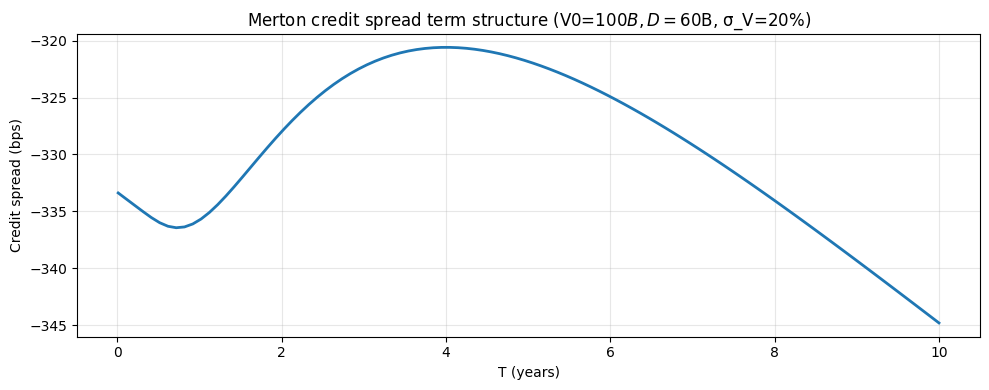


→ Spread → 0 at T = 0 (Merton "instantaneous default = 0" issue — wrong empirically).
→ Peak around T = 4.05y for this leverage.
→ Long-end falls because the option to wait is valuable.


In [5]:
T_grid = np.linspace(0.01, 10, 100)
spreads = []
for T_ in T_grid:
    E_T = merton_equity(V0, D, T_, r, sigma_V, delta)
    B_T = V0 - E_T
    spread_T = -np.log(B_T / D) / T_ - r
    spreads.append(spread_T)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(T_grid, np.array(spreads) * 1e4, lw=2)
ax.set_xlabel('T (years)'); ax.set_ylabel('Credit spread (bps)')
ax.set_title(f'Merton credit spread term structure (V0=${V0}B, D=${D}B, σ_V={sigma_V:.0%})')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print('\n→ Spread → 0 at T = 0 (Merton "instantaneous default = 0" issue — wrong empirically).')
print(f'→ Peak around T = {T_grid[np.argmax(spreads)]:.2f}y for this leverage.')
print('→ Long-end falls because the option to wait is valuable.')

## Exercises

### Exercise 1 — Distance to default for varying leverage

Compute DD for leverage from 30% to 90% (D ranging from $30B to $90B, V0 = $100B). Plot. Where is DD critical (DD < 1)?

In [6]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
leverage_grid = np.linspace(0.3, 0.9, 13)
DD_grid = [merton_distance_to_default(100, lev*100, 1.0, 0.06, 0.20) for lev in leverage_grid]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(leverage_grid * 100, DD_grid, 'o-')
ax.axhline(1.0, color='red', ls='--', label='DD = 1 (critical)')
ax.set_xlabel('Leverage (%)'); ax.set_ylabel('Distance to Default (σ)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

print('Critical leverage (DD < 1):', [f'{lev:.0%}' for lev, dd in zip(leverage_grid, DD_grid) if dd < 1])
```

_DD < 1 typically at leverage > 80% for these params._

</details>

### Exercise 2 — Sensitivity of PD to asset vol

For our firm, plot Q-PD as σ_V varies from 0.10 to 0.50. What does the relationship look like?

In [7]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
sigma_grid = np.linspace(0.05, 0.50, 30)
PDs = [merton_pd_riskneutral(100, 60, 1.0, 0.043, sV, 0.02) for sV in sigma_grid]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sigma_grid * 100, np.array(PDs) * 100, 'o-')
ax.set_xlabel('σ_V (%)'); ax.set_ylabel('Q-PD (%)')
ax.set_title('PD vs asset volatility'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print('→ PD rises steeply with σ_V. Doubling vol triples PD at high vol.')
```

_PD increases monotonically with σ_V, especially in the tail._

</details>

### Exercise 3 — Equity option implied PD

If you observe a deep OTM put on a stock that would only be ITM if the firm defaults, the put price implies a PD. For our firm with $E_0 \approx \$43B$ and σ_E = 35%: a put with strike $K \to 0$ pays $K - E_T$ if firm defaults. Use BS to back out the firm's PD from this put price.

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
E_obs, sigma_E_obs = E_0, 0.35
K_put_low = 5  # very low strike
T_put = 1.0
# BS put on equity (treating equity as if it were the underlying with σ_E)
def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

# A put price provides info about extreme downside; in the limit K → 0 it approaches an
# Arrow-Debreu price for "equity goes to 0" event. For our purposes, just compare:
put_price = bs_put(E_obs, K_put_low, T_put, r, sigma_E_obs)
print(f'BS put @ K=5, σ_E=35%: ${put_price:.6f}B')
print('→ Real-world: deep OTM puts include a "credit risk" premium not captured by BS lognormality.')
```

_Deep OTM put prices in equity options reflect default risk._

</details>

## Interview Q&A

**Q: State the Merton 1974 model.**

A: A firm has assets $V_t$ following GBM, debt $D$ maturing at $T$. At maturity, equity = $\max(V_T - D, 0)$ — a European call on assets struck at debt face. By no-arbitrage, equity at time 0 is the BS call. PD = $N(-d_2)$ under risk-neutral measure.

**Q: Why is equity a call?**

A: Equityholders have a **residual** claim — they get whatever's left after debt is paid. If $V_T < D$, equity gets nothing (limited liability). If $V_T > D$, equity gets the excess. That's the call payoff.

**Q: What's distance to default?**

A: $\text{DD} = (\ln V_0 - \ln D + (\mu_V - \tfrac{1}{2}\sigma_V^2) T) / (\sigma_V \sqrt{T})$. Number of σ that $\ln V_T$ is above $\ln D$. Higher DD → safer firm. KMV translates DD to PD via an empirical mapping, not the Merton $N(-DD)$ — because real PDs are systematically higher than Merton predicts.

**Q: How do you back out $V_0, \sigma_V$ from $E_0, \sigma_E$?**

A: Two equations, two unknowns: (1) $E_0 = $ BS-call $(V_0, D, T, r, \sigma_V)$, (2) $\sigma_E E_0 = V_0 e^{-\delta T} N(d_1) \sigma_V$ from Itô applied to $E = E(V, t)$. Solve via Newton or fsolve. KMV runs this iteratively daily on every public firm.

**Q: What's the credit spread puzzle?**

A: Merton spreads at short maturities → 0 (no default in infinitesimal time). Empirical IG spreads are 50-150 bps even at 1y. Merton ignores: (1) jumps in asset value, (2) endogenous default — firm can default before $T$ if assets fall, (3) liquidity premium, (4) tax / regulatory effects. Modern extensions: Black-Cox 1976 (continuous default barrier), Leland-Toft 1996 (optimal capital structure), structural-with-jumps.

**Q: Risk-neutral vs real-world PD?**

A: Risk-neutral PD is the rate at which the *market* prices default — it's what's used for pricing CDS and risky bonds. Real-world (physical) PD is the actual probability of default — used for risk management. Q-PD > P-PD because the market includes a risk premium for default risk.

**Q: How do you price a CDS in the structural framework?**

A: CDS premium ≈ q × LGD where q is the hazard rate (instantaneous default rate) and LGD is loss given default. Under Merton: hazard rate at $t$ = $-\partial \ln(\text{survival})/\partial t$. Simple form for exponential decay: spread × (1-recovery) ≈ hazard rate.

**Q: Merton vs reduced-form (intensity) models?**

A:
- **Merton (structural)**: PD comes from asset dynamics. Connects to firm fundamentals. **Underpredicts short-dated spreads.**
- **Reduced-form**: hazard rate is exogenous. Calibrated to CDS quotes directly. **Doesn't connect to firm fundamentals.** Used for marking, not for fundamental analysis.
- Both have a place: structural for "what does this firm's risk look like", reduced-form for "what's the market saying".

**Q: Does Merton work for sovereigns?**

A: Less directly — sovereigns don't have "assets" in the same sense. Sovereign credit models use macro factors (debt/GDP, fiscal flow) instead. Reduced-form is preferred for sovereigns; structural for corporates.

## Pitfalls reference card

| Pitfall | Issue | Fix |
|---|---|---|
| Equating Q-PD with P-PD | Different measures, different drift | State which you're computing |
| Solving the 2D system without good initial guess | fsolve fails | Use $V \approx E + D$ and $\sigma_V \approx \sigma_E \cdot E / V$ as start |
| Treating $V_t$ as observable | It isn't for a real firm | Imply from equity market via the 2D system |
| Treating $D$ as constant face | Real firms have multiple debt tranches | Use a single "effective" debt level; or stratify with multiple barriers |
| Single-period horizon | Merton model is single-T; real firms have continuous default risk | Black-Cox extension: continuous default barrier |
| Ignoring jumps | Spread puzzle | Use jump-diffusion (Merton-style + Poisson jumps to default) |
| Constant volatility assumption | $\sigma_V$ varies through time | Stochastic-vol structural models (Geske 1977 compound options for multi-tranche) |
| Equity vol vs option-implied vol | Historical vs forward-looking | Use ATM forward implied vol from option market |

## What you've earned

After this notebook you can:

1. **State and derive** the Merton structural model: equity = call on assets struck at debt face.
2. **Compute** PD (Q and P), distance to default, equity value from $V_0, \sigma_V$.
3. **Back out** unobservable $V_0, \sigma_V$ from observable $E_0, \sigma_E$ via 2D system.
4. **Compute** Merton-implied credit spreads and explain the credit spread puzzle.
5. **Plot** the spread term structure and interpret its shape.
6. **Defend** the structural framework in interview, connect to KMV/Moody's, distinguish from reduced-form.

Next: **`04_portfolio/04_factor_models.ipynb`** — Fama-French factor returns, factor exposures, and performance attribution.